<a href="https://colab.research.google.com/github/ayobami4/Final-Year-Project/blob/main/Final_Year_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification of ECG signals using Kohonen self-organising maps (SOM)

# Importing the libraries

In [1]:
%pip install minisom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from matplotlib.patches import Patch

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=034a148e5a563723714df835d2d9c818b2c70642925b91057bcfd010c6c35e0c
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


# Loading the dataset

In [2]:
df = pd.read_csv('Heart_Disease_Prediction.csv')

# Displaying the first 5 rows of the DataFrame

In [3]:
display(df.head())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


# Displaying basic information about the dataset

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

None

# Checking the unique values and their counts in the 'Heart Disease' column

In [5]:
display(df['Heart Disease'].value_counts())

,count
Heart Disease,
Absence,150
Presence,120


# Converting 'Heart Disease' column to numerical representation

# Assuming 'Presence' = 1 and 'Absence' = 0 based on the typical classification tasks

In [6]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Displaying the updated value counts to confirm the conversion

In [7]:
display(df['Heart Disease'].value_counts())

,count
Heart Disease,
0,150
1,120


# Displaying the first few rows with the updated 'Heart Disease' column

In [8]:
display(df.head())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


# Separating features (X) and target (y)

In [9]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# Splitting the dataset into training and testing sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizing the features

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (189, 13)
X_test_scaled shape: (81, 13)


# Defining the dimensions of the SOM grid

In [12]:
som_dim_x = 10
som_dim_y = 10

# Initializing the SOM

In [13]:
som = MiniSom(som_dim_x, som_dim_y, X_train_scaled.shape[1],
              sigma=0.5, learning_rate=0.5,
              neighborhood_function='gaussian', random_seed=42)

# Initializing SOM weights randomly

In [14]:
som.random_weights_init(X_train_scaled)

# Training the SOM

In [15]:
print("Training the SOM...")
som.train_random(X_train_scaled, num_iteration=1000)
print("SOM training complete.")

Training the SOM...
SOM training complete.


# Map training data to the SOM and assign labels to each neuron

In [16]:
winner_coordinates = np.array([som.winner(x) for x in X_train_scaled])

# Creating a dictionary to store the class counts for each neuron

In [17]:
neuron_labels = np.zeros((som_dim_x, som_dim_y), dtype=int)

for i in range(som_dim_x):
    for j in range(som_dim_y):
        # Getting all training samples that map to this neuron
        mapped_samples_indices = np.where((winner_coordinates[:, 0] == i) & (winner_coordinates[:, 1] == j))[0]
        if len(mapped_samples_indices) > 0:
            # Getting the labels of these samples
            labels_of_mapped_samples = y_train.iloc[mapped_samples_indices]

            # Assign the majority class to the neuron
            if not labels_of_mapped_samples.empty:
                unique_labels, counts = np.unique(labels_of_mapped_samples, return_counts=True)
                neuron_labels[i, j] = unique_labels[np.argmax(counts)]
        else:
            # If no samples map to this neuron, assign a default label
            neuron_labels[i, j] = 0

# Predicting on the test set

In [18]:
y_pred = []
for x_test_sample in X_test_scaled:
    bmu = som.winner(x_test_sample)
    y_pred.append(neuron_labels[bmu[0], bmu[1]])

y_pred = np.array(y_pred)

# Evaluating the model

In [19]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.86      0.79        49
           1       0.71      0.53      0.61        32

    accuracy                           0.73        81
   macro avg       0.72      0.69      0.70        81
weighted avg       0.73      0.73      0.72        81


Accuracy Score:
0.7283950617283951


# Computing the confusion matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix

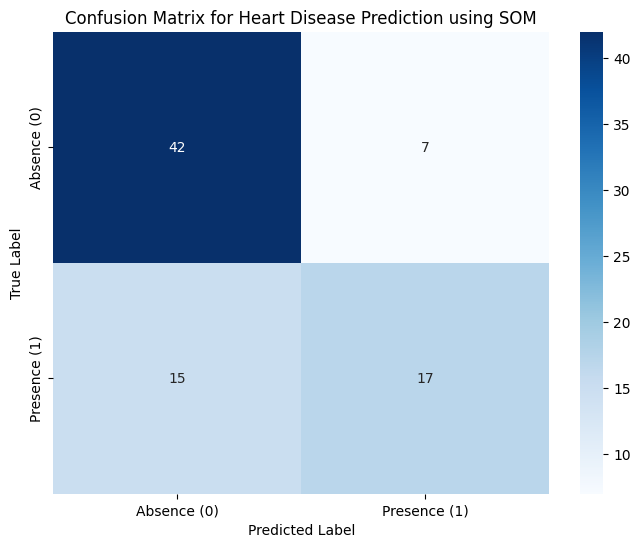

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absence (0)', 'Presence (1)'],
            yticklabels=['Absence (0)', 'Presence (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Heart Disease Prediction using SOM')
plt.show()

# Getting the winning neurons for each test sample

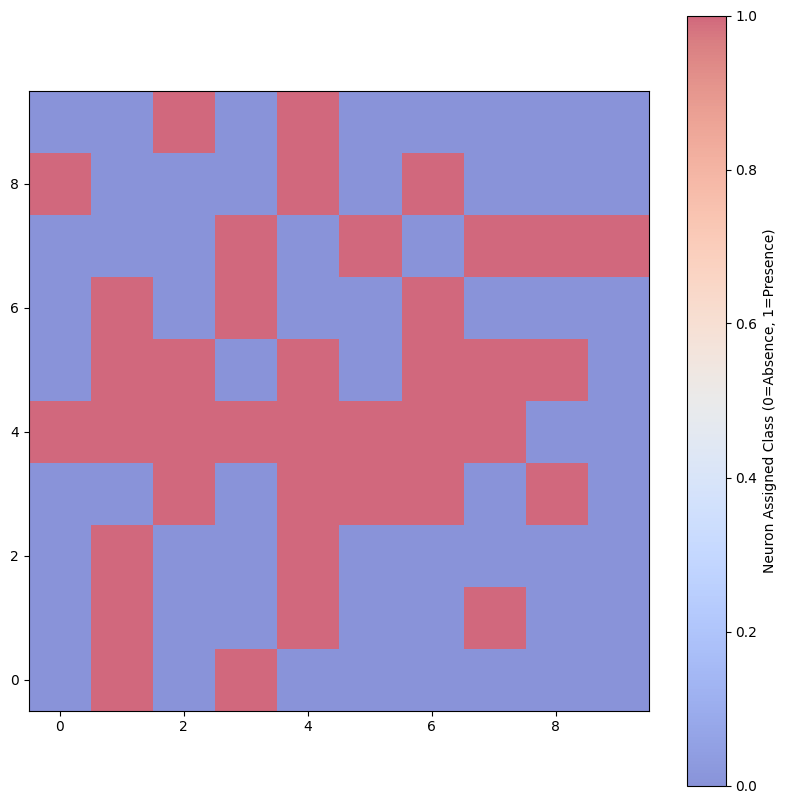

In [22]:
test_winner_coordinates = np.array([som.winner(x) for x in X_test_scaled])

plt.figure(figsize=(10, 10))
# Plotting the U-matrix to show distances between neurons

# Plotting the neuron labels as the background
plt.imshow(neuron_labels.T, cmap='coolwarm', alpha=0.6, origin='lower') # Transposing for correct orientation
plt.colorbar(label='Neuron Assigned Class (0=Absence, 1=Presence)')

# Overlaying test points with their true labels

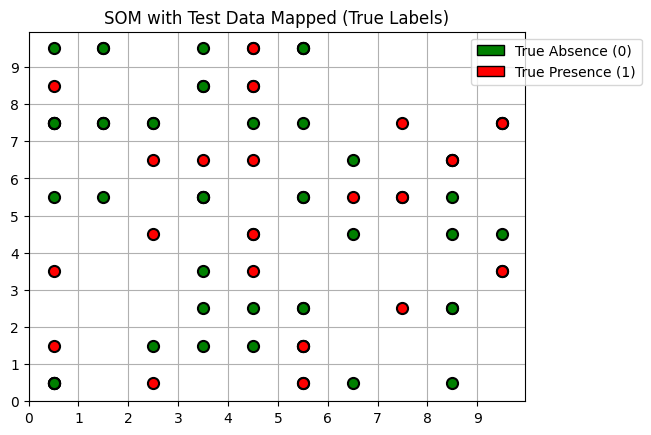

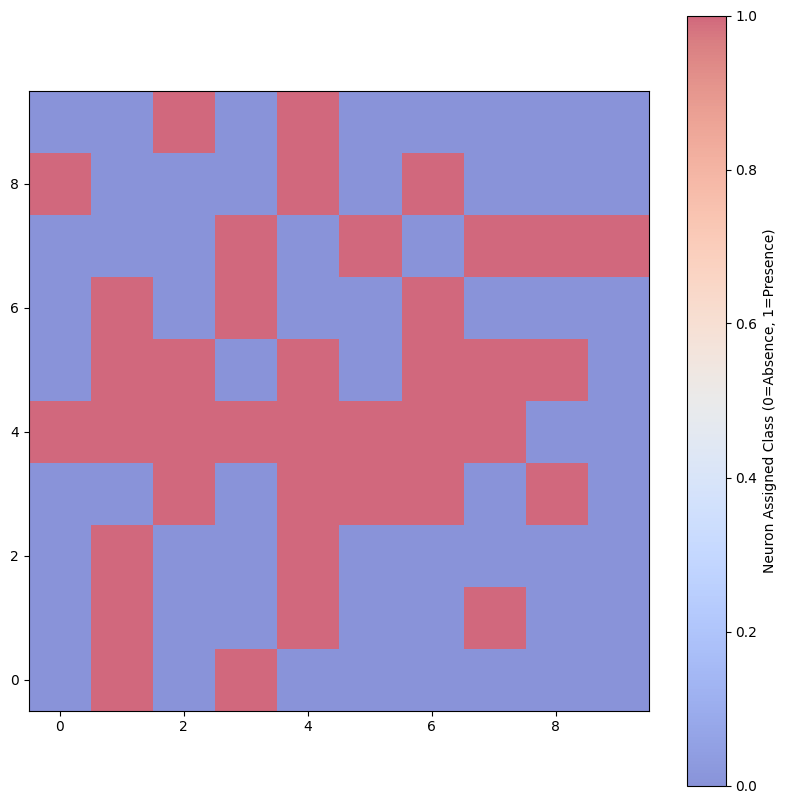

In [23]:
for i, (x_coord, y_coord) in enumerate(test_winner_coordinates):
    color = 'green' if y_test.iloc[i] == 0 else 'red'
    marker = 'o'
    plt.plot(x_coord + 0.5, y_coord + 0.5, marker, markerfacecolor=color, markeredgecolor='black', markersize=8, markeredgewidth=1.5)

plt.title('SOM with Test Data Mapped (True Labels)')
plt.xticks(np.arange(som_dim_x))
plt.yticks(np.arange(som_dim_y))
plt.grid(True)

legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='True Absence (0)'),
    Patch(facecolor='red', edgecolor='black', label='True Presence (1)')
]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

plt.figure(figsize=(10, 10))
# Plotting the neuron labels as the background
plt.imshow(neuron_labels.T, cmap='coolwarm', alpha=0.6, origin='lower') # Transposing for correct orientation
plt.colorbar(label='Neuron Assigned Class (0=Absence, 1=Presence)')


# Overlaying test points with their predicted labels

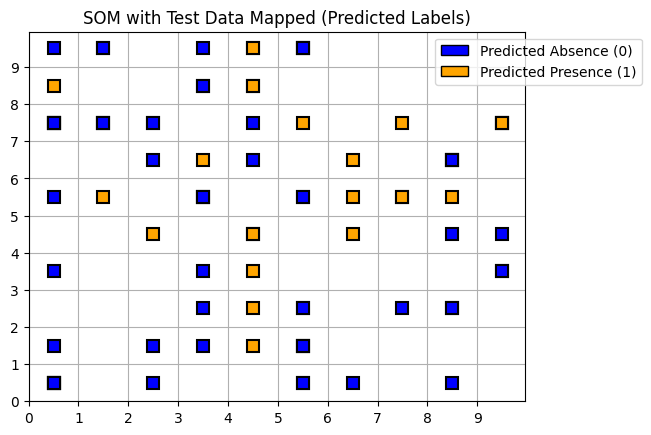

In [24]:
for i, (x_coord, y_coord) in enumerate(test_winner_coordinates):
    color = 'blue' if y_pred[i] == 0 else 'orange'
    marker = 's'
    plt.plot(x_coord + 0.5, y_coord + 0.5, marker, markerfacecolor=color, markeredgecolor='black', markersize=8, markeredgewidth=1.5)

plt.title('SOM with Test Data Mapped (Predicted Labels)')
plt.xticks(np.arange(som_dim_x))
plt.yticks(np.arange(som_dim_y))
plt.grid(True)

legend_elements_pred = [
    Patch(facecolor='blue', edgecolor='black', label='Predicted Absence (0)'),
    Patch(facecolor='orange', edgecolor='black', label='Predicted Presence (1)')
]
plt.legend(handles=legend_elements_pred, loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()